In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [14]:
#LOADING VARIABLES
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    # variable='qc'; qc_data=data[variable].data # get qc data
    # variable='qi'; qi_data=data[variable].data # get qc data
    # qc_plus_qi=qc_data+qi_data

    print('done loading')
    emptylike=True

loading neccessary variables
done loading


In [ ]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [11]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/job_array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [ ]:
###########################################################################################################################################################################

In [2]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')


ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels


In [3]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_nz=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_nz=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(SHALLOW_out_nz)} CL parcels and {len(SHALLOW_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 1152 CL parcels and 1048 nonCL parcels


In [4]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #4km
DEEP_out_nz=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_nz=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(DEEP_out_nz)} CL parcels and {len(DEEP_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 374 CL parcels and 314 nonCL parcels


In [5]:
#GET 3D Entrainment Array ***
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles_ENTRAINGOOD.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [20]:
#ALL
def data_collect(out_nz,type):
    profile_array_e=profile_array_e_g.copy()
    
    zh=data['zh'].values
    if type=='above_below':
        #Above and Below LFC
        
        ws=[];qvs=[]; es=[]
        zs_lst=[]
        
        nummins=20; numsteps=int(nummins/times[1])
        
        for ind in np.arange(out_nz.shape[0]):
            row=out_nz[ind]
            ts=np.arange(row[4],row[5]+numsteps+1)
            p=row[0]
            zs=Z[ts,p];ys=Y[ts,p];xs=X[ts,p]
            
            w_row=w_data[ts,zs,ys,xs]; ws.extend(w_row)
            qv_row=qv_data[ts,zs,ys,xs]; qvs.extend(qv_row)
            e_row=profile_array_e[ts,zs,ys,xs]; es.extend(e_row) #USING PRECALCULATED 3D ENTRAINMENT ARRAY

            zs_lst.extend(zs)
    if type=='below':
        #Below LFC
        zhs=data['zh'].values*1000 #TESTING
        # lfc_data=data['lfc'].data #TESTING
        
        ws=[];qvs=[]; es=[]
        zs_lst=[]
        
        nummins=20; numsteps=int(nummins/times[1])
        for ind in np.arange(out_nz.shape[0]):
            row=out_nz[ind]
            ts=np.arange(row[4],row[5]+numsteps+1)
            p=row[0]
            zs=Z[ts,p];ys=Y[ts,p];xs=X[ts,p]
        
            # lfc_row=lfc_data[ts,ys,xs] #TESTING
            lfc_row=1.56*1000
            where=np.where(zhs[zs]<=lfc_row) #TESTING
        
            ts=ts[where];zs=zs[where];ys=ys[where];xs=xs[where]
            
            w_row=w_data[ts,zs,ys,xs]; ws.extend(w_row)
            qv_row=qv_data[ts,zs,ys,xs]; qvs.extend(qv_row)
            e_row=profile_array_e[ts,zs,ys,xs]; es.extend(e_row)

            zs_lst.extend(zs)
    if type=='above':
        #Above LFC
        zhs=data['zh'].values*1000 #TESTING
        # lfc_data=data['lfc'].data #TESTING
        
        ws=[];qvs=[]; es=[]
        zs_lst=[]
        
        nummins=20; numsteps=int(nummins/times[1])
        for ind in np.arange(out_nz.shape[0]):
            row=out_nz[ind]
            ts=np.arange(row[4],row[5]+numsteps+1)
            p=row[0]
            zs=Z[ts,p];ys=Y[ts,p];xs=X[ts,p]
        
            # lfc_row=lfc_data[ts,ys,xs] #TESTING
            lfc_row=1.56*1000
            where=np.where(zhs[zs]>=lfc_row) #TESTING
        
            ts=ts[where];zs=zs[where];ys=ys[where];xs=xs[where]
            
            w_row=w_data[ts,zs,ys,xs]; ws.extend(w_row)
            qv_row=qv_data[ts,zs,ys,xs]; qvs.extend(qv_row)
            e_row=profile_array_e[ts,zs,ys,xs]; es.extend(e_row)

            zs_lst.extend(zs)

    zs_lst=[zh[lst] for lst in zs_lst]
    return ws,qvs,es,zs_lst

In [16]:
def LR(axis,var1,var2,zorder):
    coeffs = np.polyfit(var1, var2, 1)  # Fit a line (degree 1)
    line = np.poly1d(coeffs)        # Create a polynomial function
    
    # Plot the fitted line
    x_vals = np.linspace(min(var1), max(var1), 100)  # Generate x-values for the line
    y_vals = line(x_vals)                        # Calculate corresponding y-values
    axis.plot(x_vals, y_vals, color='red',zorder=zorder)

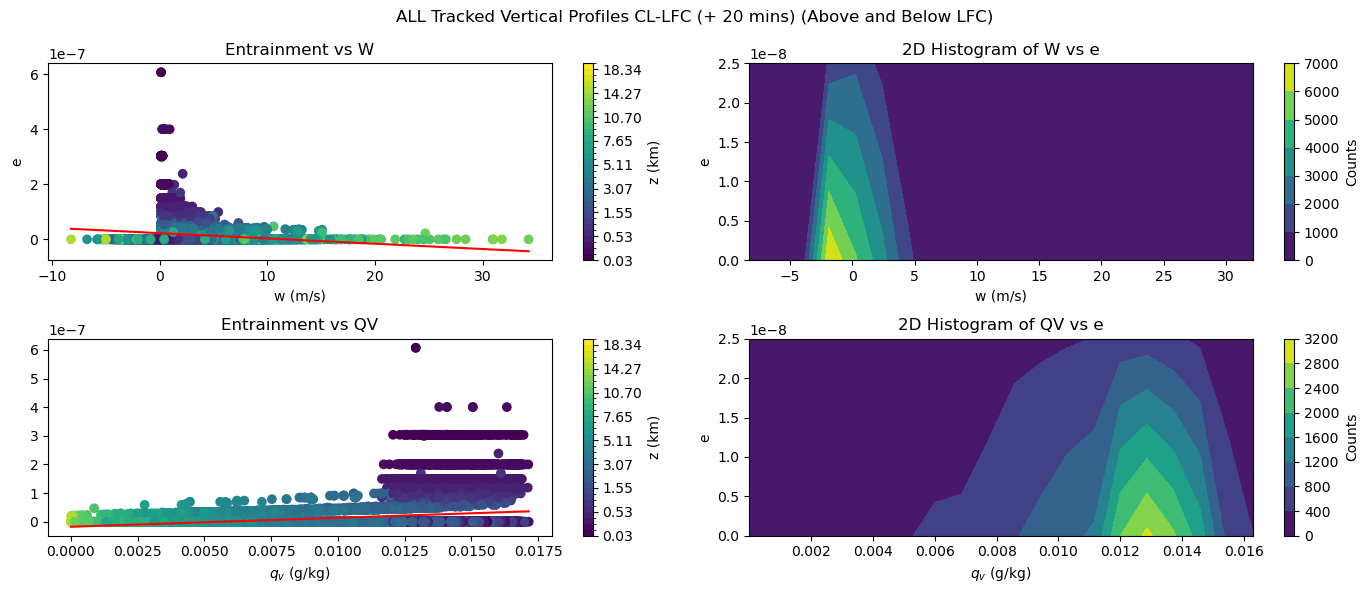

In [21]:
[ws,qvs,es,zs_lst]=data_collect(ALL_out_nz,type='above_below')


# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

#LR
LR(ax1,ws,es,zorder=3)

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm,zorder=1)#color='blue')

#LR
LR(ax3,qvs,es,zorder=3)

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('ALL Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
plt.tight_layout()



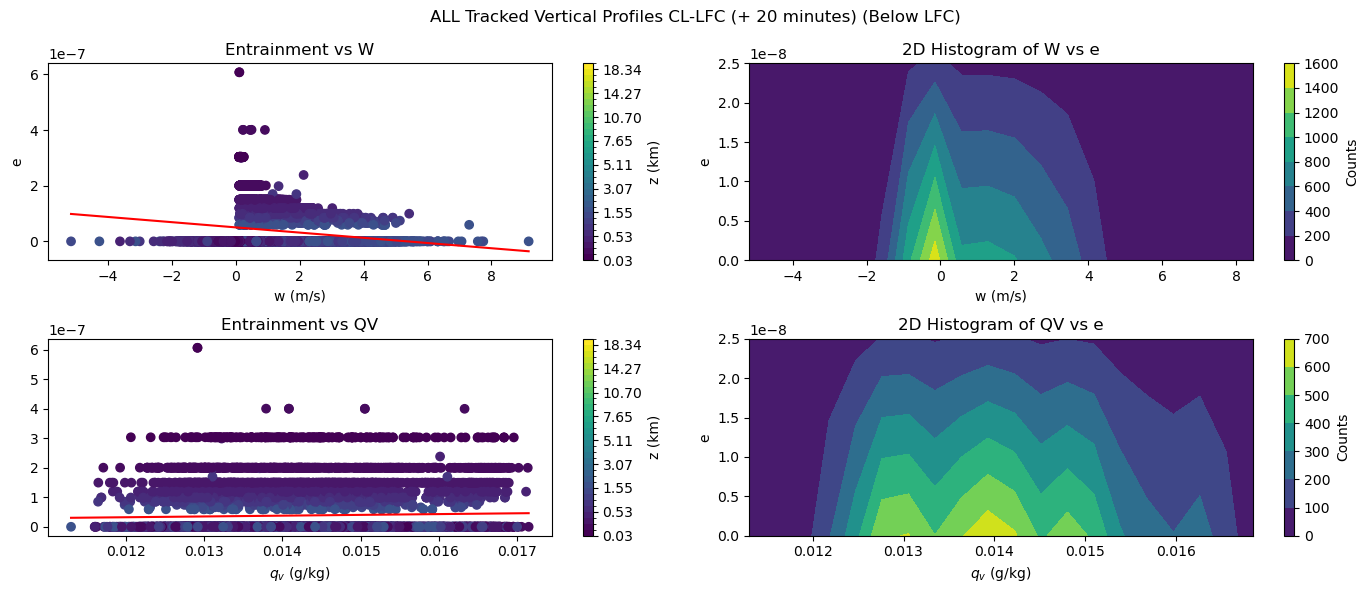

In [22]:
[ws,qvs,es,zs_lst]=data_collect(ALL_out_nz,type='below')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

#LR
LR(ax1,ws,es,zorder=3)

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

#LR
LR(ax3,qvs,es,zorder=3)

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
plt.tight_layout()



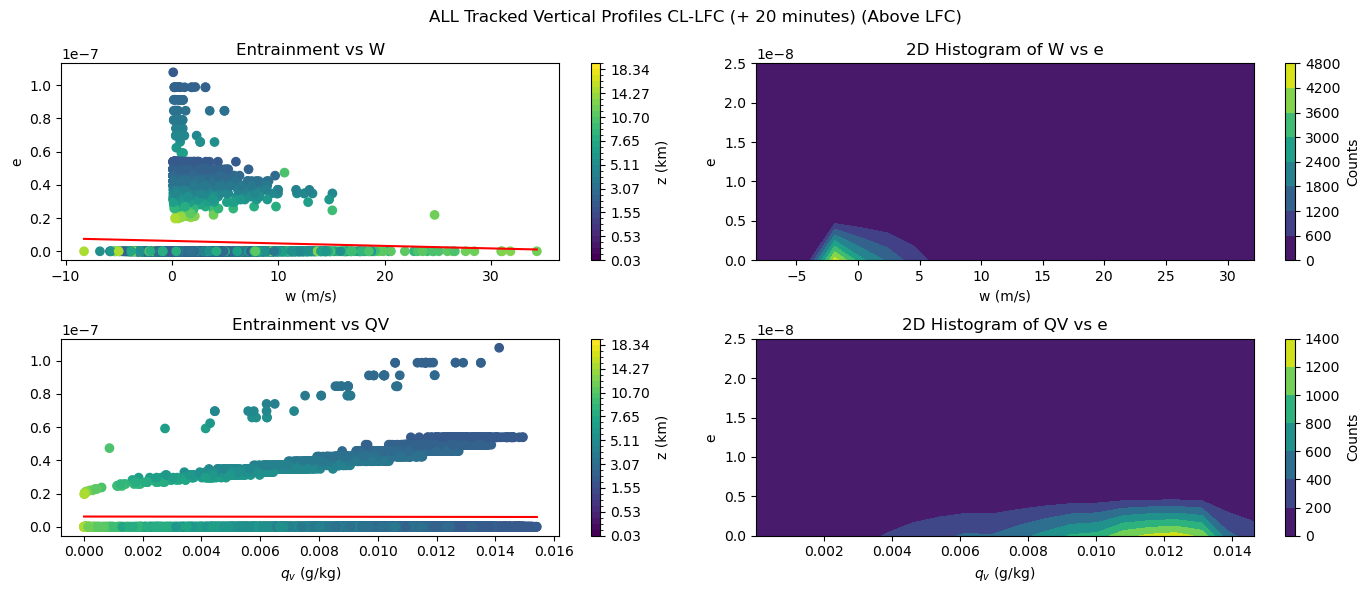

In [23]:
[ws,qvs,es,zs_lst]=data_collect(ALL_out_nz,type='above')

# Create a figure and GridSpec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
ax1 = plt.subplot(gs[0,0])  
ax2 = plt.subplot(gs[0,1]) 

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

#LR
LR(ax1,ws,es,zorder=3)

# Labels
cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
ax1.set_xlabel('w (m/s)')
ax1.set_ylabel('e')
ax1.set_title('Entrainment vs W')
# ax1.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax2.set_aspect('auto')

# Set labels and title for ax2
ax2.set_ylim((0,0.25e-7))
ax2.set_xlabel('w (m/s)')
ax2.set_ylabel('e')
ax2.set_title('2D Histogram of W vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# ##############################

# Create subplots using GridSpec
ax3 = plt.subplot(gs[1,0])  # Left subplot
ax4 = plt.subplot(gs[1,1])  # Right subplot

# Plot on ax1 (scatter plot with line)
import matplotlib.colors as mcolors
z_levels = data['zh'].values  # 34 z levels
cmap = plt.cm.viridis  # You can choose another colormap
norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

#LR
LR(ax3,qvs,es,zorder=3)

cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
ax3.set_xlabel(r'$q_v$ (g/kg)')
ax1.set_ylabel('e')
ax3.set_title('Entrainment vs QV')
# ax3.legend()

# Create a 2D histogram
hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# Plot the histogram as a contour on ax2
c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# Set aspect ratio for ax2
ax4.set_aspect('auto')

# Set labels and title for ax2
ax4.set_ylim((0,0.25e-7))
ax4.set_xlabel(r'$q_v$ (g/kg)')
ax4.set_ylabel('e')
ax4.set_title('2D Histogram of QV vs e')

# Create a colorbar for ax2
cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

plt.suptitle('ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
plt.tight_layout()



In [ ]:
# # SHALLOW
# [ws,qvs,es,zs_lst]=data_collect(SHALLOW_out_nz,type='above_below')


# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('SHALLOW Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
# plt.tight_layout()



In [ ]:
# [ws,qvs,es,zs_lst]=data_collect(SHALLOW_out_nz,type='below')

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('SHALLOW Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
# plt.tight_layout()



In [ ]:
# [ws,qvs,es,zs_lst]=data_collect(SHALLOW_out_nz,type='above')

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('SHALLOW Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
# plt.tight_layout()



In [ ]:
# # DEEP
# [ws,qvs,es,zs_lst]=data_collect(DEEP_out_nz,type='above_below')


# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('DEEP Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
# plt.tight_layout()



In [ ]:
# [ws,qvs,es,zs_lst]=data_collect(DEEP_out_nz,type='below')

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('DEEP Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
# plt.tight_layout()



In [ ]:
# [ws,qvs,es,zs_lst]=data_collect(DEEP_out_nz,type='above')

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('DEEP  Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
# plt.tight_layout()



In [ ]:
# #ALL SBZ
# #SBZ vs nonSBZ 
# #############################################################

# #FINDING SBZ CONVERGENCE

# #FIND ALL X MAXES
# import sys
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# path=dir+'../Functions'
# sys.path.append(path)
# # import inspect
# # functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# # functions

# TF=False
# if TF==False:
#     print('Loading In Data')
#     u_data=data['u'].interp(xf=data['xh']).data
#     v_data=data['v'].interp(yf=data['yh']).data
#     TF=True


# from NumericalFunctions import *
# def find_SBZ_xmaxs():
    
#     print('calculating convergence and taking mean')
#     Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    
#     zlev=4
#     Conv_ymean=np.mean(Conv[:,zlev],axis=1)
#     xmaxs=np.argmax(Conv_ymean, axis=1)

#     return xmaxs

# # SUBSETTING OUT SBZS

# def subset_SBZ(out_nz):
#     xmaxs=find_SBZ_xmaxs()

#     SBZ_subset=[]
#     # test=[] #TESTING
    
#     for ind in np.arange(out_nz.shape[0]):
        
#         row=out_nz[ind]
#         p=row[0]
#         t=row[4]

#         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
#         if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
#             SBZ_subset.append(ind)
#             # test.append(p) #TESTING
    
#     SBZ_out_nz=out_nz[SBZ_subset]
#     print(f'there are a total of {len(SBZ_out_nz)} ALL SBZ CL parcels')

#     valid_range=np.arange(out_nz.shape[0])
#     nonSBZ_out_nz=out_nz[list(set(valid_range) - set(SBZ_subset))]
#     print(f'there are a total of {len(nonSBZ_out_nz)} ALL nonSBZ CL parcels')
#     return SBZ_out_nz,nonSBZ_out_nz
# ##############################################################
# [ALL_SBZ_out_nz,ALL_nonSBZ_out_nz]=subset_SBZ(out_nz)

In [9]:
# # SBZ ALL
# #ABOVE and BELOW LFC
# [ws,qvs,es,zs_lst]=data_collect(ALL_SBZ_out_nz,type='above_below')


# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('SBZ ALL Tracked Vertical Profiles CL-LFC (+ 20 mins) (Above and Below LFC)')
# plt.tight_layout()



In [10]:
# [ws,qvs,es,zs_lst]=data_collect(ALL_SBZ_out_nz,type='below')

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('SBZ ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Below LFC)')
# plt.tight_layout()



In [ ]:
# [ws,qvs,es,zs_lst]=data_collect(ALL_SBZ_out_nz,type='above')

# # Create a figure and GridSpec
# fig = plt.figure(figsize=(14, 6))
# gs = gridspec.GridSpec(2, 2, figure=fig)

# # Create subplots using GridSpec
# ax1 = plt.subplot(gs[0,0])  
# ax2 = plt.subplot(gs[0,1]) 

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax1.scatter(ws, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax1,ws,es,zorder=3)


# # Labels
# cbar = fig.colorbar(scatter, ax=ax1, orientation='vertical', label='z (km)')
# ax1.set_xlabel('w (m/s)')
# ax1.set_ylabel('e')
# ax1.set_title('Entrainment vs W')
# # ax1.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(ws, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax2.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax2.set_aspect('auto')

# # Set labels and title for ax2
# ax2.set_ylim((0,0.25e-7))
# ax2.set_xlabel('w (m/s)')
# ax2.set_ylabel('e')
# ax2.set_title('2D Histogram of W vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax2, orientation='vertical', label='Counts')

# # ##############################

# # Create subplots using GridSpec
# ax3 = plt.subplot(gs[1,0])  # Left subplot
# ax4 = plt.subplot(gs[1,1])  # Right subplot

# # Plot on ax1 (scatter plot with line)
# import matplotlib.colors as mcolors
# z_levels = data['zh'].values  # 34 z levels
# cmap = plt.cm.viridis  # You can choose another colormap
# norm = mcolors.BoundaryNorm(boundaries=z_levels, ncolors=cmap.N)
# scatter = ax3.scatter(qvs, es, c=zs_lst, cmap=cmap, norm=norm, zorder=1)#color='blue')

# #LR
# LR(ax3,qvs,es,zorder=3)


# cbar = fig.colorbar(scatter, ax=ax3, orientation='vertical', label='z (km)')
# ax3.set_xlabel(r'$q_v$ (g/kg)')
# ax1.set_ylabel('e')
# ax3.set_title('Entrainment vs QV')
# # ax3.legend()

# # Create a 2D histogram
# hist, x_edges, y_edges = np.histogram2d(qvs, es, bins=20)

# # Plot the histogram as a contour on ax2
# c = ax4.contourf(x_edges[:-1], y_edges[:-1], hist.T, cmap='viridis', origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

# # Set aspect ratio for ax2
# ax4.set_aspect('auto')

# # Set labels and title for ax2
# ax4.set_ylim((0,0.25e-7))
# ax4.set_xlabel(r'$q_v$ (g/kg)')
# ax4.set_ylabel('e')
# ax4.set_title('2D Histogram of QV vs e')

# # Create a colorbar for ax2
# cbar = fig.colorbar(c, ax=ax4, orientation='vertical', label='Counts')

# plt.suptitle('SBZ ALL Tracked Vertical Profiles CL-LFC (+ 20 minutes) (Above LFC)')
# plt.tight_layout()

